In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from IPython.core.interactiveshell import InteractiveShell

In [4]:
# 加载数据
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

缺失值分析


缺失值数量
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


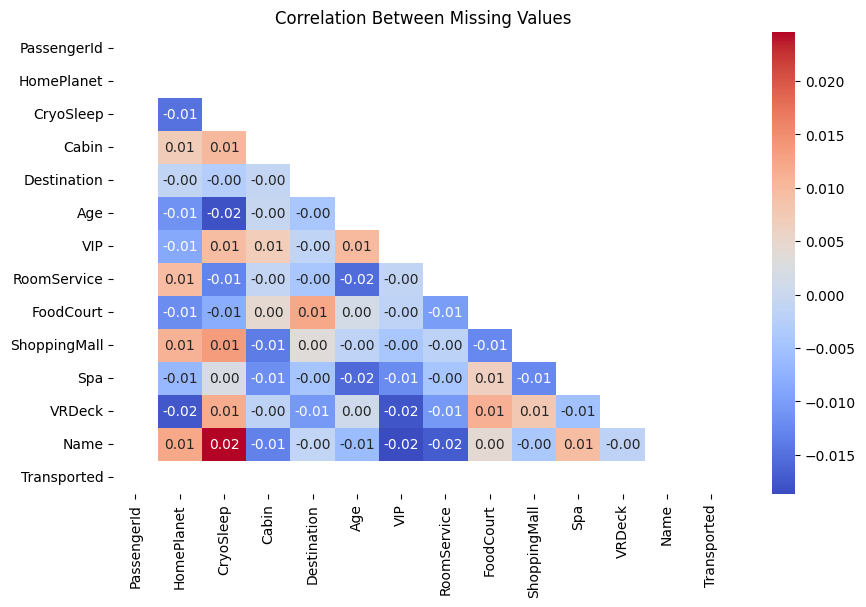

In [5]:
# 缺失值数量
print("\n缺失值数量")
print(train.isnull().sum())

# 生成缺失值指示矩阵（1=缺失，0=存在）
missing_indicator = train.isnull().astype(int)

# 计算缺失值之间的相关性
missing_corr = missing_indicator.corr()

# 绘制热力图
plt.figure(figsize=(10, 6))
sns.heatmap(missing_corr, annot=True, cmap='coolwarm', fmt=".2f", 
            mask=np.triu(np.ones_like(missing_corr, dtype=bool)))
plt.title("Correlation Between Missing Values", fontsize=12)
plt.show()

发现缺失值相关性很弱

缺失值处理

1.若 CryoSleep=True，则所有消费字段应为0

In [6]:
initial_count = len(train)
train_dropped = train.dropna()
remaining_ratio = len(train_dropped) / initial_count
print(f"移除所有缺失行后剩余数据比例: {remaining_ratio:.2%}")

移除所有缺失行后剩余数据比例: 75.99%


2. 其它缺失值处理

In [7]:
initial_count = len(train)
train_dropped = train.dropna()
remaining_ratio = len(train_dropped) / initial_count
print(f"移除所有缺失行后剩余数据比例: {remaining_ratio:.2%}")

移除所有缺失行后剩余数据比例: 75.99%


最终选择直接删除

In [8]:
# 导出到csv
train_processed = train_dropped
train_processed.to_csv('train_processed_missing.csv',index = 'PassengerId')